# Diabetes Risk Prediction 
Dataset: Pima Indians Diabetes Database (Kaggle)  
Target: `Outcome` (1 = diabetic, 0 = healthy)

## 1 · Imports & Data Load

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report,
                             confusion_matrix, roc_curve)
from xgboost import XGBClassifier
import joblib, json

df = pd.read_csv("../data/diabetes.csv")
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 2 · EDA 

In [4]:
print("Class balance:")
print(df['Outcome'].value_counts())

# Biologically implausible zeros (encoded missing values)
zero_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']
for col in zero_cols:
    print(f"  {col} zeros: {(df[col]==0).sum()}")

Class balance:
Outcome
0    500
1    268
Name: count, dtype: int64
  Glucose zeros: 5
  BloodPressure zeros: 35
  SkinThickness zeros: 227
  Insulin zeros: 374
  BMI zeros: 11


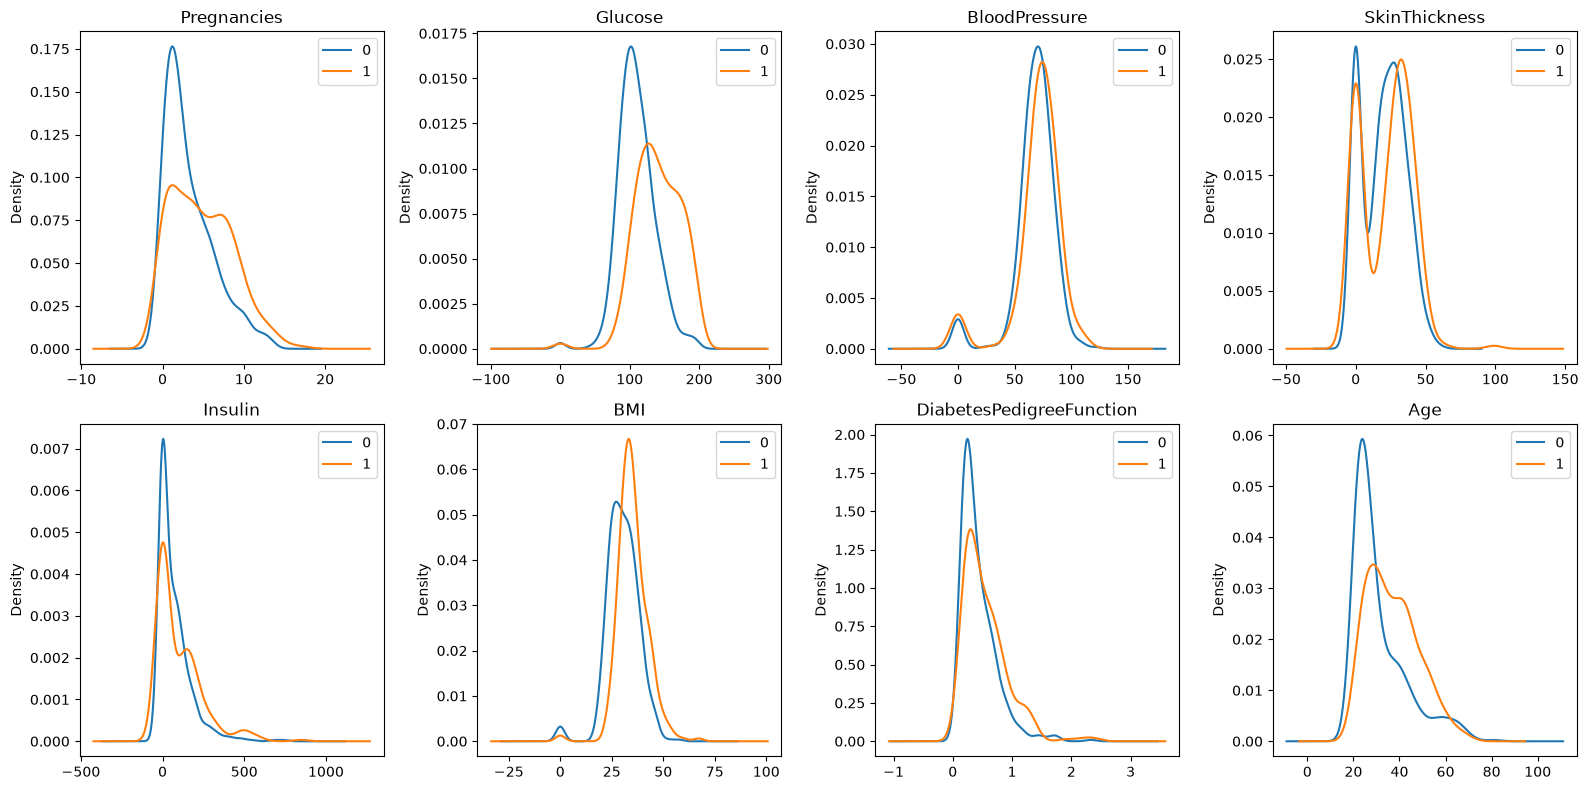

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, col in enumerate(df.columns[:-1]):
    ax = axes[i//4][i%4]
    df.groupby('Outcome')[col].plot(kind='kde', ax=ax, legend=True)
    ax.set_title(col)
plt.tight_layout(); plt.show()

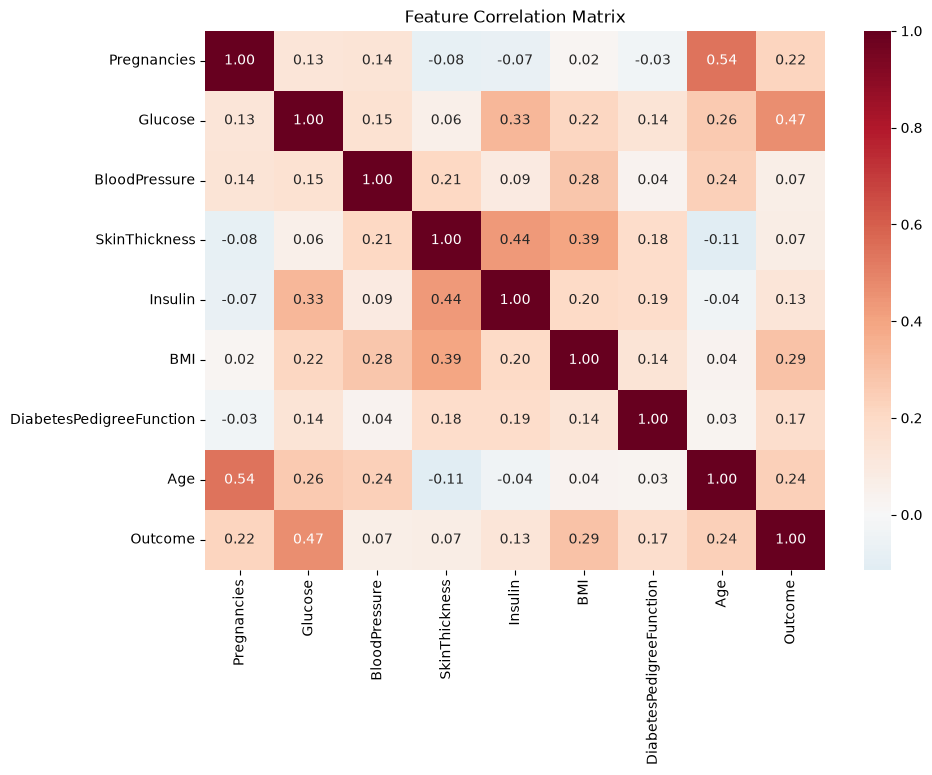

In [6]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title("Feature Correlation Matrix"); plt.show()

## 3 · Feature Engineering & Field Mapping


In [7]:
df['Glucose'] = df['Glucose'].replace(0, np.nan)
df['BMI']     = df['BMI'].replace(0, np.nan)

df['hypertension']      = (df['BloodPressure'] >= 90).astype(int)
df['family_history']    = (df['DiabetesPedigreeFunction'] > 0.5).astype(int)
df['physical_activity'] = np.where(df['BMI'].isna(), 1, (df['BMI'] < 30).astype(int))
df['smoker']            = 0  # SYNTHETIC: all 0 in training

FEATURES = ['Age','Glucose','BMI','hypertension','family_history','physical_activity','smoker']
X = df[FEATURES].rename(columns={'Age':'age','Glucose':'glucose','BMI':'bmi'})
y = df['Outcome']
print(X.head())

   age  glucose   bmi  hypertension  family_history  physical_activity  smoker
0   50    148.0  33.6             0               1                  0       0
1   31     85.0  26.6             0               0                  1       0
2   32    183.0  23.3             0               1                  1       0
3   21     89.0  28.1             0               0                  1       0
4   33    137.0  43.1             0               1                  0       0


## 4 · Preprocessing Pipeline

In [8]:
def make_pipe(clf):
    return Pipeline([('imputer', SimpleImputer(strategy='median')),
                     ('scaler',  StandardScaler()),
                     ('clf',     clf)])

## 5 · Train / Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print("Train class balance:", y_train.value_counts().to_dict())

Train: (614, 7), Test: (154, 7)
Train class balance: {0: 400, 1: 214}


## 6 · Model Training & Comparison

In [10]:
candidates = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest':       RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost':            XGBClassifier(n_estimators=200, random_state=42,
                                        eval_metric='logloss', verbosity=0),
}
results = {}; pipes = {}
for name, clf in candidates.items():
    p = make_pipe(clf); p.fit(X_train, y_train)
    yp  = p.predict(X_test)
    ypr = p.predict_proba(X_test)[:,1]
    results[name] = {'accuracy':  round(accuracy_score(y_test,yp),4),
                     'precision': round(precision_score(y_test,yp),4),
                     'recall':    round(recall_score(y_test,yp),4),
                     'f1':        round(f1_score(y_test,yp),4),
                     'roc_auc':   round(roc_auc_score(y_test,ypr),4)}
    pipes[name] = p

pd.DataFrame(results).T.sort_values('roc_auc', ascending=False)

,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.7273,0.6364,0.5185,0.5714,0.7931
RandomForest,0.7273,0.6200,0.5741,0.5962,0.7908
XGBoost,0.7208,0.6279,0.5000,0.5567,0.7602


## 7 · Evaluation 

Best model: LogisticRegression


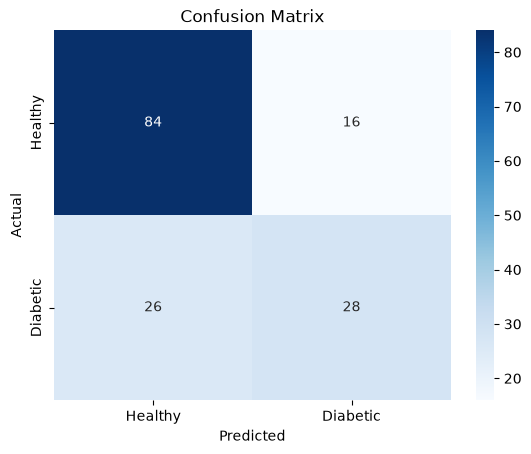

              precision    recall  f1-score   support

     Healthy       0.76      0.84      0.80       100
    Diabetic       0.64      0.52      0.57        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.69       154
weighted avg       0.72      0.73      0.72       154



In [11]:
best_name = max(results, key=lambda k: results[k]['roc_auc'])
print(f"Best model: {best_name}")
best = pipes[best_name]

y_pred  = best.predict(X_test)
y_proba = best.predict_proba(X_test)[:,1]

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy','Diabetic'], yticklabels=['Healthy','Diabetic'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix'); plt.show()

# Classification report
print(classification_report(y_test, y_pred, target_names=['Healthy','Diabetic']))

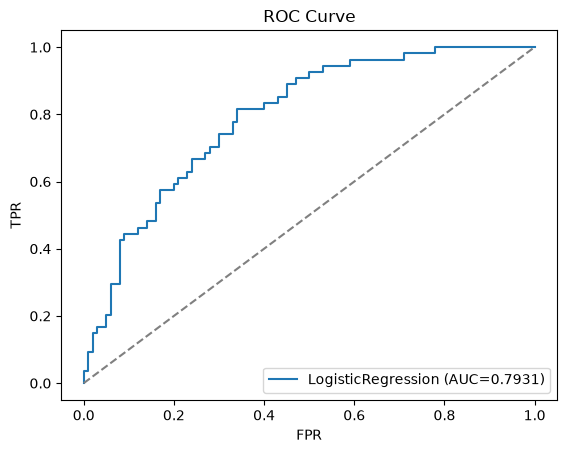

In [12]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label=f'{best_name} (AUC={results[best_name]["roc_auc"]})')
plt.plot([0,1],[0,1],'--', color='grey'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC Curve'); plt.legend(); plt.show()

## 8 · Save Model & Metrics

In [14]:
joblib.dump(best, '../models/diabetes_model.joblib')

metrics = {**results[best_name], 'model': best_name,
           'features': list(X.columns), 'test_size': 0.2, 'random_state': 42}
with open('../metrics/diabetes_metrics.json','w') as f: json.dump(metrics,f,indent=2)
print(json.dumps(metrics, indent=2))

{
  "accuracy": 0.7273,
  "precision": 0.6364,
  "recall": 0.5185,
  "f1": 0.5714,
  "roc_auc": 0.7931,
  "model": "LogisticRegression",
  "features": [
    "age",
    "glucose",
    "bmi",
    "hypertension",
    "family_history",
    "physical_activity",
    "smoker"
  ],
  "test_size": 0.2,
  "random_state": 42
}
